<div align="center">

# MAE575 Coding Project – Milestone 1

## Jared Brinkley  

### 3/10/2026

</div>

1.) Reproduce figures 5-7 for the scramjet engine described in the paper
<div align="center">

![](Figure5.png "Figure 5")

## Figure 5

![](Figure6.png "Figure 6")

## Figure 6

![](Figure7.png "Figure 7")

## Figure 7
</div>

$$
\begin{aligned}
\textbf{(1) Gas equation of state:} \qquad
& \frac{dp}{p} - \frac{d\rho}{\rho} - \frac{dT}{T} = 0 \\[8pt]

\textbf{(2) Differential form of Mach number:} \qquad
& \frac{dM^2}{M^2} - \frac{dV^2}{V^2} + \frac{dT}{T} = 0 \\[8pt]

\textbf{(3) Conservation of mass:} \qquad
& \frac{d\rho}{\rho} + \frac{dV}{V} + \frac{dA_c}{A_c} = 0 \\[8pt]

\textbf{(4) Conservation of momentum:} \qquad
& \frac{dp}{p}
+ \frac{\gamma M^2}{2}\frac{4C_f\,dx}{D}
+ \frac{\gamma M^2}{2}\frac{A_c}{A}\frac{dV^2}{V^2}
= 0 \\[8pt]

\textbf{(5) Conservation of energy:} \qquad
& \frac{dT}{T}
+ \frac{\gamma - 1}{2} M^2 \frac{dV^2}{V^2}
=
\left(1 + \frac{\gamma - 1}{2} M^2 \right)
\frac{dT_t}{T_t}
\end{aligned}
$$

In [6]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import root
import matplotlib.pyplot as plt

# -------------------------
# Given / used for Figs 5-7
# -------------------------
x2 = 0.0
x3 = 0.2   # fuel injection / combustor start
x4 = 0.5   # combustor end

phi_total = 0.5          # Figure 5
eta_tot = 0.8
vartheta = 5.0
Cf_const = 0.002

# thermo model (piecewise constants, per paper)
iso = dict(gamma=1.37, R=287.0, cp=1063.0)
cmb = dict(gamma=1.31, R=297.0, cp=1255.0)

# station 2 conditions used in Fig 5 caption
M2 = 2.65
p2 = 50e3
T2 = 650.0

# heat release (hydrogen)
hpr = 120e6              # J/kg-fuel
fst = 0.0290             # stoich fuel/air (mass), H2-air ~ 0.029

A_ratio_end = 2.0        # A(x4)/A2 = 2 (linear diverging combustor)

In [7]:
def A_over_A2(x):
    # isolator: constant area
    if x <= x3:
        return 1.0
    # combustor: linear divergence to area ratio 2 at x4
    return 1.0 + (A_ratio_end - 1.0) * (x - x3) / (x4 - x3)

def dlnA_dx(x):
    Ar = A_over_A2(x)
    if x <= x3:
        return 0.0
    # A = A2 * (1 + k*(x-x3)); so d(ln A)/dx = (1/A) dA/dx = k / (1 + k*(x-x3))
    k = (A_ratio_end - 1.0) / (x4 - x3)
    return k / Ar

def D_h_over_D2(x):
    # round duct: D ∝ sqrt(A) → D/D2 = sqrt(A/A2)
    return np.sqrt(A_over_A2(x))

def mixing_efficiency(x):
    # X = (x-x3)/(x4-x3)
    if x <= x3:
        return 0.0
    X = (x - x3) / (x4 - x3)
    X = np.clip(X, 0.0, 1.0)
    # ηc = ηtot * X / (ϑ + (1-ϑ) X)  (as written in the paper around eq. 11)
    return eta_tot * (X / (vartheta + (1.0 - vartheta)*X))

def d_eta_dx(x):
    if x <= x3:
        return 0.0
    X = (x - x3) / (x4 - x3)
    X = np.clip(X, 0.0, 1.0)
    denom = (vartheta + (1.0 - vartheta)*X)
    deta_dX = eta_tot * (vartheta / (denom**2))  # derivative of X/denom
    return deta_dX * (1.0 / (x4 - x3))

In [8]:
from scipy.optimize import root
import numpy as np

def total_temperature(T, M, gamma):
    return T * (1.0 + 0.5*(gamma - 1.0)*M**2)

def flow_from_pTM(p, T, M, gamma, R):
    a = np.sqrt(gamma * R * T)
    V = M * a
    rho = p / (R * T)
    return rho, V

# upstream state at x3- (isolator side)
gamma1, R1, cp1 = iso["gamma"], iso["R"], iso["cp"]
rho_u, V_u = flow_from_pTM(p2, T2, M2, gamma1, R1)

G_u  = rho_u * V_u                       # mass flux
J_u  = p2 + rho_u * V_u**2               # momentum flux
Tt_u = total_temperature(T2, M2, gamma1)
Ht_u = cp1 * Tt_u                        # total enthalpy per mass
E_u  = G_u * Ht_u                        # total enthalpy flux

# combustor-side props
gamma2, R2, cp2 = cmb["gamma"], cmb["R"], cmb["cp"]

def boundary_residual(z):
    # unknowns: [M, p, T]
    M, p, T = z
    if M <= 0 or p <= 0 or T <= 0:
        return np.array([1e6, 1e6, 1e6])

    rho, V = flow_from_pTM(p, T, M, gamma2, R2)
    G = rho * V
    J = p + rho * V**2
    Tt = total_temperature(T, M, gamma2)
    Ht = cp2 * Tt
    E = G * Ht

    return np.array([G - G_u, J - J_u, E - E_u])

z0 = np.array([M2, p2, T2])   # good initial guess
sol = root(boundary_residual, z0, method="hybr")
if not sol.success:
    raise RuntimeError(sol.message)

M3, p3, T3 = sol.x
Tt3 = total_temperature(T3, M3, gamma2)

print(f"x=0.2 m match: M3={M3:.4f}, p3={p3/1e3:.2f} kPa, T3={T3:.2f} K, Tt3={Tt3:.2f} K")

x=0.2 m match: M3=3.0246, p3=40.90 kPa, T3=523.50 K, Tt3=1265.82 K


In [9]:
def attached_rhs(x, y, props, D2=0.06):
    M2_local, p, T, Tt = y
    gamma, R, cp = props["gamma"], props["R"], props["cp"]

    M = np.sqrt(max(M2_local, 1e-12))

    # independent "inputs"
    a_lnA = dlnA_dx(x)  # (1/A) dA/dx
    D = D2 * D_h_over_D2(x)
    f = (4.0 * Cf_const) / D  # (4 Cf)/D

    # heat addition to total temperature
    if x <= x3:
        dTt_dx = 0.0
    else:
        dHt_dx = hpr * fst * phi_total * d_eta_dx(x)
        dTt_dx = dHt_dx / cp

    tt = dTt_dx / max(Tt, 1e-12)  # (1/Tt) dTt/dx

    # Solve linear system for:
    # u1 = (1/p) dp/dx
    # u2 = (1/T) dT/dx
    # u3 = (1/M^2) d(M^2)/dx
    # with S = u3 + u2 = (1/V^2) d(V^2)/dx

    # Equations (per dx form):
    # (5) u1 + (γ M^2)/2 * f + (γ M^2)/2 * (u3+u2) = 0
    # (6) u2 + (γ-1)/2 M^2 * (u3+u2) = (1+(γ-1)/2 M^2) * tt
    # (4)+(7)+(8) -> u1 - u2 + 0.5*(u3+u2) + a_lnA = 0

    A = np.zeros((3,3))
    b = np.zeros(3)

    # eq (5)
    A[0,0] = 1.0
    A[0,1] = 0.5*gamma*M2_local
    A[0,2] = 0.5*gamma*M2_local
    b[0] = -0.5*gamma*M2_local * f

    # eq (6)
    A[1,0] = 0.0
    A[1,1] = 1.0 + 0.5*(gamma-1.0)*M2_local
    A[1,2] = 0.5*(gamma-1.0)*M2_local
    b[1] = (1.0 + 0.5*(gamma-1.0)*M2_local) * tt

    # eq (4)+(7)+(8)
    A[2,0] = 1.0
    A[2,1] = -1.0 + 0.5
    A[2,2] = 0.5
    b[2] = -a_lnA

    u1, u2, u3 = np.linalg.solve(A, b)

    dp_dx  = p  * u1
    dT_dx  = T  * u2
    dM2_dx = M2_local * u3

    return np.array([dM2_dx, dp_dx, dT_dx, dTt_dx])

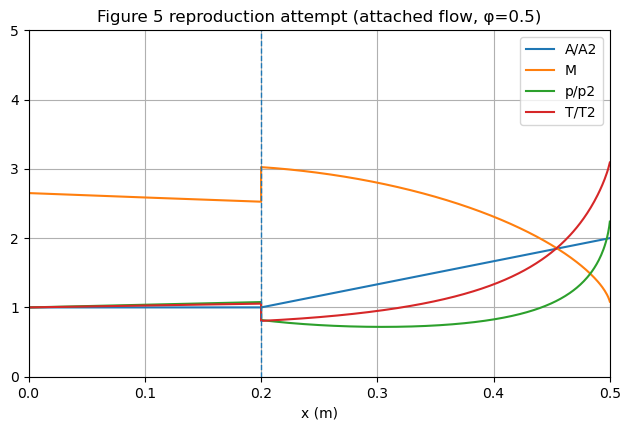

Peak p/p2: 2.23818182642705
Peak T/T2: 3.091816588507591
Min M: 1.0829190383595035


In [10]:
# integrate isolator segment with iso props (no heat release, constant A)
y0_iso = np.array([M2**2, p2, T2, total_temperature(T2, M2, iso["gamma"])])
sol_iso = solve_ivp(lambda x,y: attached_rhs(x, y, iso),
                    t_span=(x2, x3), y0=y0_iso,
                    max_step=1e-3, rtol=1e-7, atol=1e-9)

# initial conditions at combustor start after boundary match
Tt3 = Ht_u / cmb["cp"]
y0_cmb = np.array([M3**2, p3, T3, Tt3])

sol_cmb = solve_ivp(lambda x,y: attached_rhs(x, y, cmb),
                    t_span=(x3, x4), y0=y0_cmb,
                    max_step=1e-3, rtol=1e-7, atol=1e-9)

# stitch
x = np.concatenate([sol_iso.t, sol_cmb.t])
M = np.sqrt(np.concatenate([sol_iso.y[0], sol_cmb.y[0]]))
p = np.concatenate([sol_iso.y[1], sol_cmb.y[1]])
T = np.concatenate([sol_iso.y[2], sol_cmb.y[2]])

A = np.array([A_over_A2(xi) for xi in x])

# nondimensional plotted quantities like in Fig 5
p_over_p2 = p / p2
T_over_T2 = T / T2

plt.figure(figsize=(7.5,4.5))
plt.plot(x, A, label="A/A2")
plt.plot(x, M, label="M")
plt.plot(x, p_over_p2, label="p/p2")
plt.plot(x, T_over_T2, label="T/T2")
plt.axvline(x3, linestyle="--", linewidth=1)

plt.xlabel("x (m)")
plt.ylim(0, 5)
plt.xlim(x2, x4)
plt.grid(True)
plt.legend()
plt.title("Figure 5 reproduction attempt (attached flow, φ=0.5)")
plt.show()

print("Peak p/p2:", p_over_p2.max())
print("Peak T/T2:", T_over_T2.max())
print("Min M:", M.min())